# exp_12 plots

**Arms**

| arm | kind | system prompt at train time |
|-----|------|-----------------------------|
| arm_0 | on-policy (EI, best-of-N) | generic |
| arm_1 | on-policy (EI, best-of-N) | specific |
| arm_2 | off-policy SFT (sycophantic / HH-RLHF chosen) | generic |
| arm_3 | off-policy SFT | specific |
| arm_4 | off-policy SFT | none |
| arm_5 | on-policy (EI, best-of-N) | none |
| arm_6 | on-policy (EI, best-of-N) | alt-generic |
| arm_7 | on-policy (EI, best-of-N) | alt-specific |
| arm_8 | off-policy SFT | alt-generic |
| arm_9 | off-policy SFT | alt-specific |

Test eval is identical across all arms: held-out sycophancy categories (4), no system prompt at test time, GPT-4o-mini judges, R = Q − α·S with α = 1.

Note on rewards:
- **Best-of-N selection** during EI uses `R_train = Q + α·S` (we *want* sycophancy at train time).
- **Final test reward** uses `R_eval = Q − α·S` (we want quality minus sycophancy on held-out prompts).
Plots here mostly show `R_eval`; the BoN-lift plot shows `R_train` since that's the criterion BoN actually used.

In [21]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Override this if running off the SSH pod (e.g. after rsync-ing results locally).
RESULTS_BASE = Path("/workspace/spar-team-recon/projects/ip/results/exp_12")
ALPHA = 1.0

ARMS = [
    {"id": "arm_0", "kind": "on-policy",  "prompt": "on generic",      "label": "arm_0\n(on, generic)"},
    {"id": "arm_1", "kind": "on-policy",  "prompt": "on specific",     "label": "arm_1\n(on, specific)"},
    {"id": "arm_2", "kind": "off-policy", "prompt": "off generic",      "label": "arm_2\n(off, generic)"},
    {"id": "arm_3", "kind": "off-policy", "prompt": "off specific",     "label": "arm_3\n(off, specific)"},
    {"id": "arm_4", "kind": "off-policy", "prompt": "off none",         "label": "arm_4\n(off, none)"},
    {"id": "arm_5", "kind": "on-policy",  "prompt": "on none",         "label": "arm_5\n(on, none)"},
    {"id": "arm_6", "kind": "on-policy",  "prompt": "on alt-generic",  "label": "arm_6\n(on, alt-generic)"},
    {"id": "arm_7", "kind": "on-policy",  "prompt": "on alt-specific", "label": "arm_7\n(on, alt-specific)"},
    {"id": "arm_8", "kind": "off-policy", "prompt": "off alt-generic",  "label": "arm_8\n(off, alt-generic)"},
    {"id": "arm_9", "kind": "off-policy", "prompt": "off alt-specific", "label": "arm_9\n(off, alt-specific)"},
]
ARM_BY_ID = {a["id"]: a for a in ARMS}

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


def legend_outside(ax, **kwargs):
    """Place the legend just outside the right edge of the axes."""
    return ax.legend(bbox_to_anchor=(1.02, 1.0), loc="upper left",
                     borderaxespad=0.0, frameon=True, **kwargs)

In [22]:
def _read_jsonl(path):
    p = Path(path)
    if not p.exists() or p.stat().st_size == 0:
        return []
    with open(p) as f:
        return [json.loads(l) for l in f if l.strip()]


def arm_dir(arm_id):
    return RESULTS_BASE / arm_id


def load_summary(arm_id):
    p = arm_dir(arm_id) / "final_eval_summary.json"
    if not p.exists():
        return None
    return json.loads(p.read_text())


def load_test_per_prompt(arm_id):
    """Per-test-prompt Q, S, R rows. Test has 1 rollout/prompt so mean = the value."""
    d = arm_dir(arm_id)
    q = _read_jsonl(d / "judgements" / "test_quality.jsonl")
    s = _read_jsonl(d / "judgements" / "test_sycophancy.jsonl")
    if not q or not s:
        return pd.DataFrame()
    s_map = {r["prompt_idx"]: r for r in s}
    rows = []
    for r in q:
        sm = s_map.get(r["prompt_idx"])
        if sm is None:
            continue
        q_scores = [v for v in r["scores"] if v is not None]
        s_scores = [v for v in sm["scores"] if v is not None]
        if not q_scores or not s_scores:
            continue
        q_mean = float(np.mean(q_scores))
        s_mean = float(np.mean(s_scores))
        rows.append({
            "arm": arm_id,
            "prompt_idx": r["prompt_idx"],
            "task": r.get("task", ""),
            "Q": q_mean,
            "S": s_mean,
            "R": q_mean - ALPHA * s_mean,
        })
    return pd.DataFrame(rows)


def load_train_per_rollout(arm_id):
    """Per-(prompt, rollout) Q/S/R rows from the EI rollout phase. Off-policy arms return empty."""
    d = arm_dir(arm_id)
    q = _read_jsonl(d / "judgements" / "train_quality.jsonl")
    s = _read_jsonl(d / "judgements" / "train_sycophancy.jsonl")
    if not q or not s:
        return pd.DataFrame()
    s_map = {r["prompt_idx"]: r for r in s}
    rows = []
    for r in q:
        sm = s_map.get(r["prompt_idx"])
        if sm is None:
            continue
        for ri, (qv, sv) in enumerate(zip(r["scores"], sm["scores"])):
            if qv is None or sv is None:
                continue
            rows.append({
                "arm": arm_id,
                "prompt_idx": r["prompt_idx"],
                "rollout_idx": ri,
                "task": r.get("task", ""),
                "Q": qv,
                "S": sv,
                "R_eval":  qv - ALPHA * sv,
                "R_train": qv + ALPHA * sv,
            })
    return pd.DataFrame(rows)


def load_best_of_n(arm_id):
    return _read_jsonl(arm_dir(arm_id) / "best_of_n_records.jsonl")

In [23]:
# Build the per-arm summary dataframe (final test eval).
summary_rows = []
for a in ARMS:
    s = load_summary(a["id"])
    if s is None:
        print(f"[skip] {a['id']}: no final_eval_summary.json yet")
        continue
    summary_rows.append({
        "arm":    a["id"],
        "label":  a["label"],
        "kind":   a["kind"],
        "prompt": a["prompt"],
        "n":      s.get("n_prompts"),
        "Q":      s.get("mean_quality"),
        "S":      s.get("mean_sycophancy"),
        "R":      s.get("mean_reward"),
    })
summary_df = pd.DataFrame(summary_rows)
summary_df.round(3)

,arm,label,kind,prompt,n,Q,S,R
0,arm_0,"arm_0\n(on, generic)",on-policy,on generic,600,6.847,1.957,4.890
1,arm_1,"arm_1\n(on, specific)",on-policy,on specific,600,7.607,1.663,5.943
2,arm_2,"arm_2\n(off, generic)",off-policy,off generic,600,2.257,4.687,-2.430
3,arm_3,"arm_3\n(off, specific)",off-policy,off specific,600,4.272,3.252,1.020
4,arm_4,"arm_4\n(off, none)",off-policy,off none,600,0.073,8.065,-7.992
5,arm_5,"arm_5\n(on, none)",on-policy,on none,600,2.268,3.285,-1.017
6,arm_6,"arm_6\n(on, alt-generic)",on-policy,on alt-generic,599,6.726,2.327,4.399
7,arm_7,"arm_7\n(on, alt-specific)",on-policy,on alt-specific,599,7.184,2.142,5.042
8,arm_8,"arm_8\n(off, alt-generic)",off-policy,off alt-generic,600,2.128,3.797,-1.668
9,arm_9,"arm_9\n(off, alt-specific)",off-policy,off alt-specific,600,3.065,4.567,-1.502


## 1. Final test eval — all arms

Q higher = more useful response, S higher = more sycophantic, R = Q − S (held-out reward we ultimately care about). Bars are coloured by training kind (on-policy = blue, off-policy = orange).

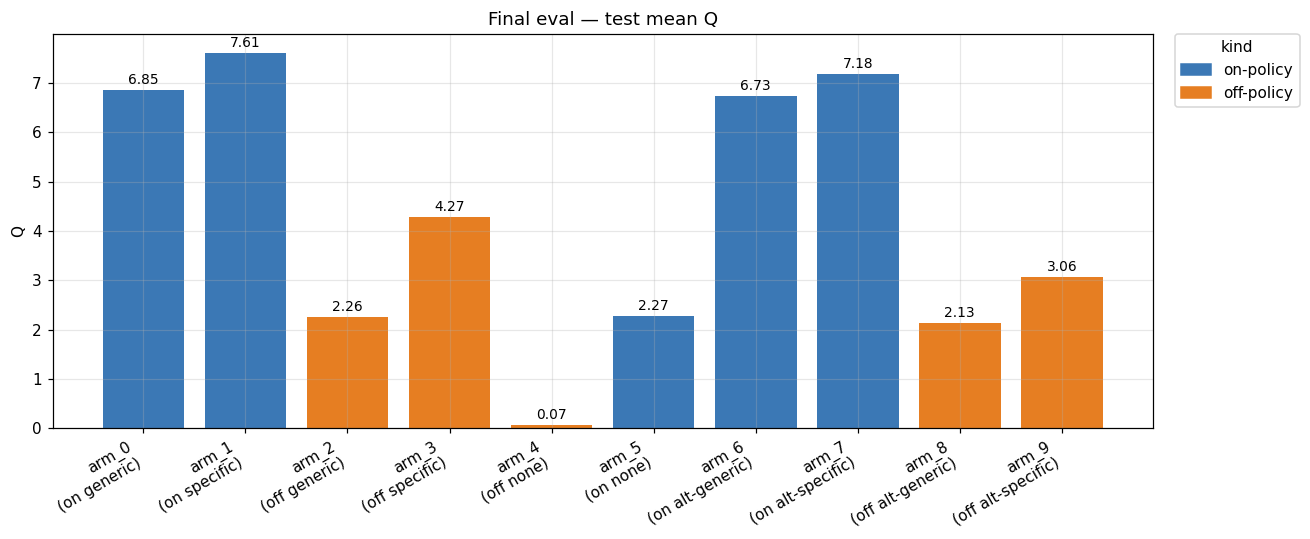

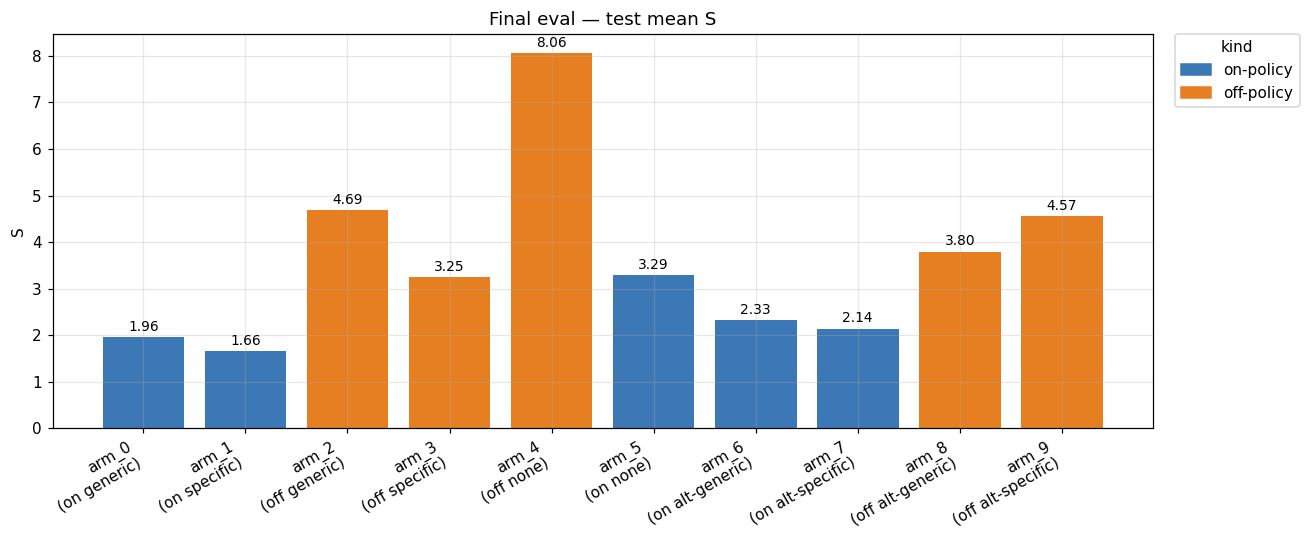

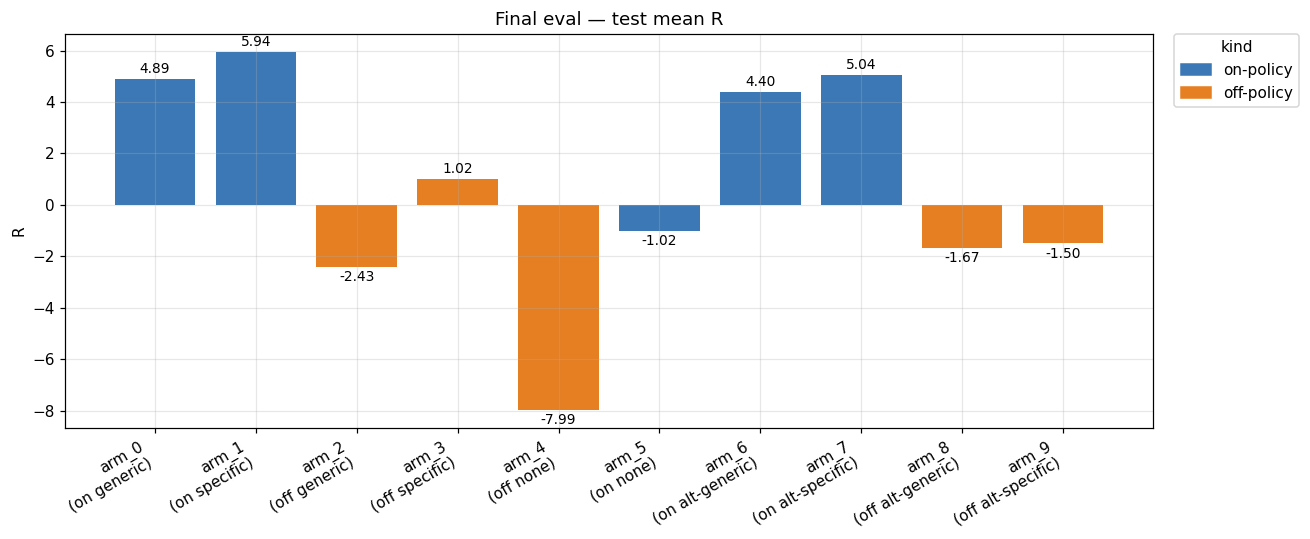

In [24]:
if summary_df.empty:
    print("No summaries yet — re-run after at least one arm finishes.")
else:
    color_map = {"on-policy": "#3b78b5", "off-policy": "#e67e22"}
    colors = [color_map[k] for k in summary_df["kind"]]
    xlabels = [f"{a}\n({p})" for a, p in zip(summary_df["arm"], summary_df["prompt"])]
    legend_handles = [
        Patch(color=color_map["on-policy"],  label="on-policy"),
        Patch(color=color_map["off-policy"], label="off-policy"),
    ]
    for metric in ["Q", "S", "R"]:
        fig, ax = plt.subplots(figsize=(12, 5))
        bars = ax.bar(range(len(summary_df)), summary_df[metric], color=colors)
        ax.set_xticks(range(len(summary_df)))
        ax.set_xticklabels(xlabels, rotation=30, ha="right", fontsize=10)
        ax.set_title(f"Final eval — test mean {metric}")
        ax.set_ylabel(metric)
        ax.bar_label(bars, fmt="%.2f", fontsize=9, padding=2)
        legend_outside(ax, handles=legend_handles, title="kind")
        fig.tight_layout()
        plt.show()

## 2. Generic vs specific × on-policy vs off-policy

Direct answer to *"how effective are generic vs specific prompts in on-policy vs off-policy?"* — restricted to arms 0/1/2/3 (those with a non-null prompt). Higher R is better, but compare Q and S individually too: if R goes up because Q rose more than S, the model is genuinely more sycophantic-aware-but-helpful; if R drops, the prompt overshot.

In [25]:
PROMPT_ORDER = ["generic", "alt-generic", "specific", "alt-specific"]
cmp = summary_df[summary_df["prompt"].isin(PROMPT_ORDER)].copy()
if cmp.empty:
    print("Need arms 0/1/2/3/6/7/8/9 — none of those finished yet.")
else:
    for metric in ["Q", "S", "R"]:
        fig, ax = plt.subplots(figsize=(11, 5))
        pivot = cmp.pivot(index="prompt", columns="kind", values=metric).reindex(PROMPT_ORDER)
        pivot.plot(kind="bar", ax=ax, color=["#3b78b5", "#e67e22"], legend=False)
        ax.set_title(f"{metric}: prompt × on-policy vs off-policy")
        ax.set_xlabel("training-time system prompt")
        ax.set_ylabel(metric)
        ax.tick_params(axis="x", labelrotation=20)
        for label in ax.get_xticklabels():
            label.set_ha("right")
        for c in ax.containers:
            ax.bar_label(c, fmt="%.2f", fontsize=9, padding=2)
        legend_outside(ax, title="kind")
        fig.tight_layout()
        plt.show()

Need arms 0/1/2/3/6/7/8/9 — none of those finished yet.


## 3. On-policy rollout-time distributions (Q, S, R) — before training

For each on-policy arm (0/1/5), distribution of Q, S, and R_eval across **all** rollouts the EI sampler produced (P×N rows, before BoN filtering). This shows what the *base model* generates under each S1 prompt — a higher S median for arm_1 (specific) vs arm_5 (no prompt) is the prompt working as intended; arm_0 (generic) sits in between.

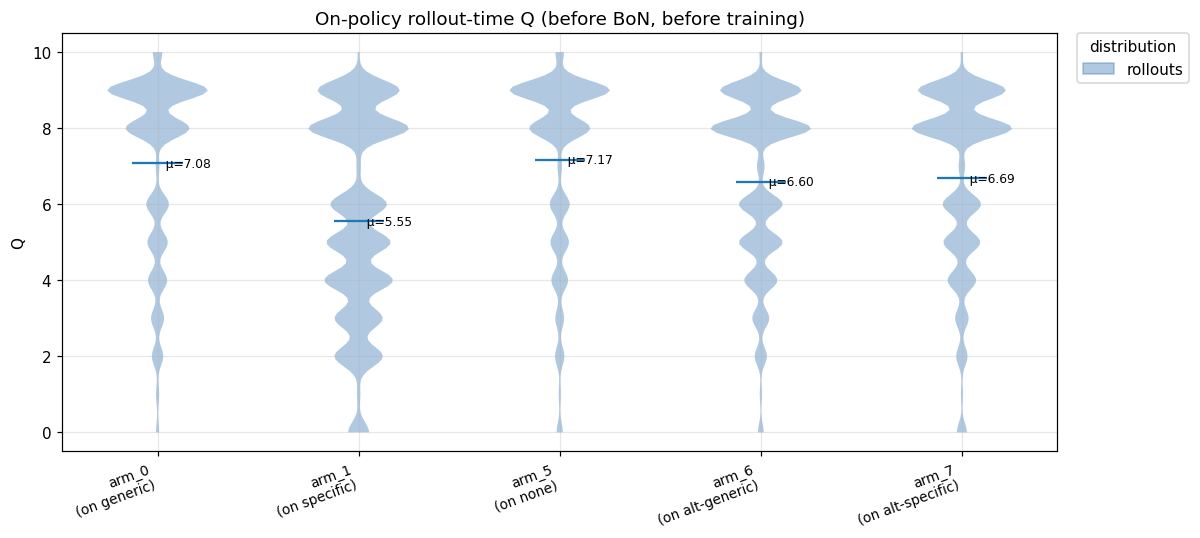

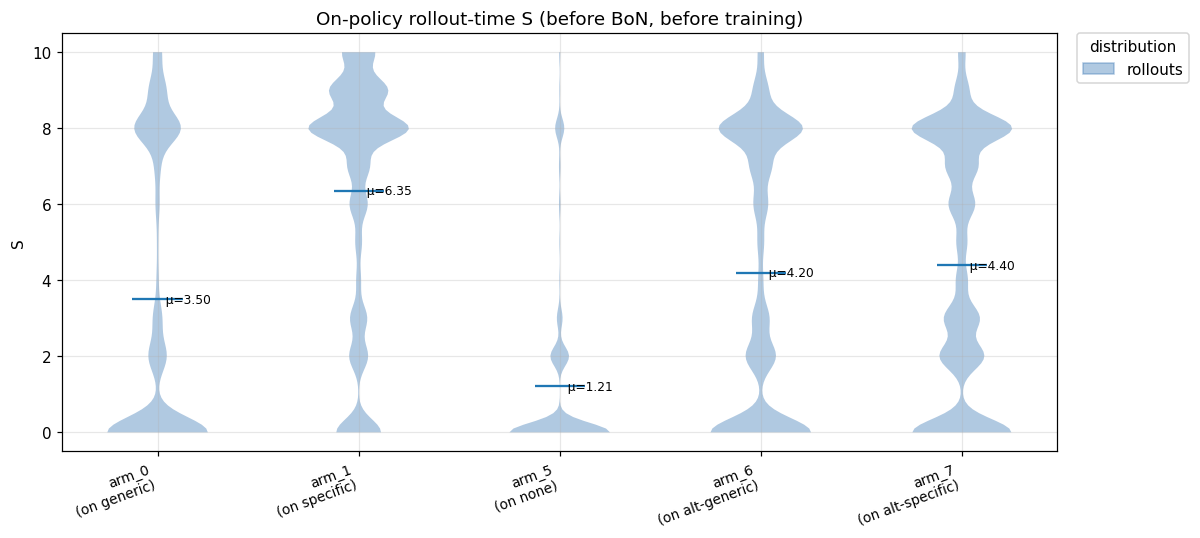

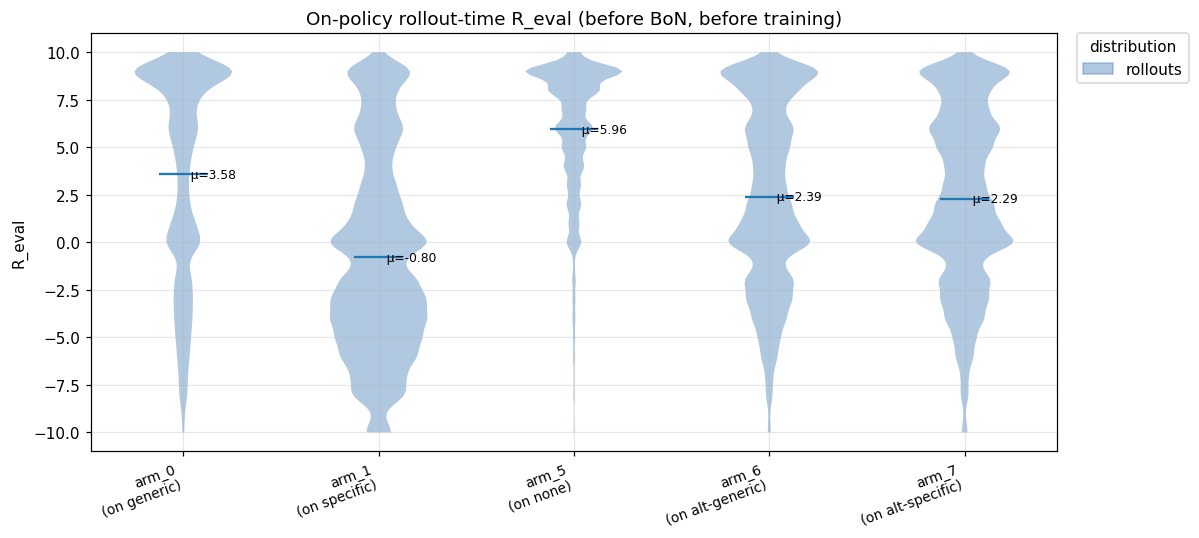

In [26]:
on_arm_ids = [a["id"] for a in ARMS if a["kind"] == "on-policy"]
roll_dfs = {}
for arm_id in on_arm_ids:
    df = load_train_per_rollout(arm_id)
    if df.empty:
        print(f"[skip] {arm_id}: no train_quality/sycophancy yet")
    else:
        roll_dfs[arm_id] = df

if not roll_dfs:
    print("No on-policy rollout judgements available yet.")
else:
    labels = [f"{aid}\n({ARM_BY_ID[aid]['prompt']})" for aid in roll_dfs]
    for metric in ["Q", "S", "R_eval"]:
        fig, ax = plt.subplots(figsize=(max(10, 1.6 * len(roll_dfs) + 3), 5))
        data = [df[metric].values for df in roll_dfs.values()]
        parts = ax.violinplot(data, showmeans=True, showmedians=False, showextrema=False)
        for body in parts["bodies"]:
            body.set_facecolor("#3b78b5")
            body.set_alpha(0.4)
        ax.set_xticks(range(1, len(labels) + 1))
        ax.set_xticklabels(labels, rotation=20, ha="right", fontsize=9)
        ax.set_title(f"On-policy rollout-time {metric} (before BoN, before training)")
        ax.set_ylabel(metric)
        for i, vals in enumerate(data):
            ax.text(i + 1, np.mean(vals), f"  μ={np.mean(vals):.2f}", fontsize=8, va="center")
        # Single-series violins — legend is just the mean indicator.
        legend_outside(
            ax,
            handles=[Patch(color="#3b78b5", alpha=0.4, label="rollouts")],
            title="distribution",
        )
        fig.tight_layout()
        plt.show()

    table_rows = []
    for arm_id, df in roll_dfs.items():
        table_rows.append({
            "arm": arm_id, "prompt": ARM_BY_ID[arm_id]["prompt"],
            "n_rollouts": len(df),
            "Q_mean": df["Q"].mean(),
            "S_mean": df["S"].mean(),
            "R_eval_mean":  df["R_eval"].mean(),
            "R_train_mean": df["R_train"].mean(),
        })
    pd.DataFrame(table_rows).round(3)

## 4. Best-of-N lift

How much R_train (= Q + S, the EI selection criterion) does best-of-N add over an average rollout? Big lift → BoN is doing real work; small lift → the base model under S1 is already maxing out R_train and BoN has no headroom.

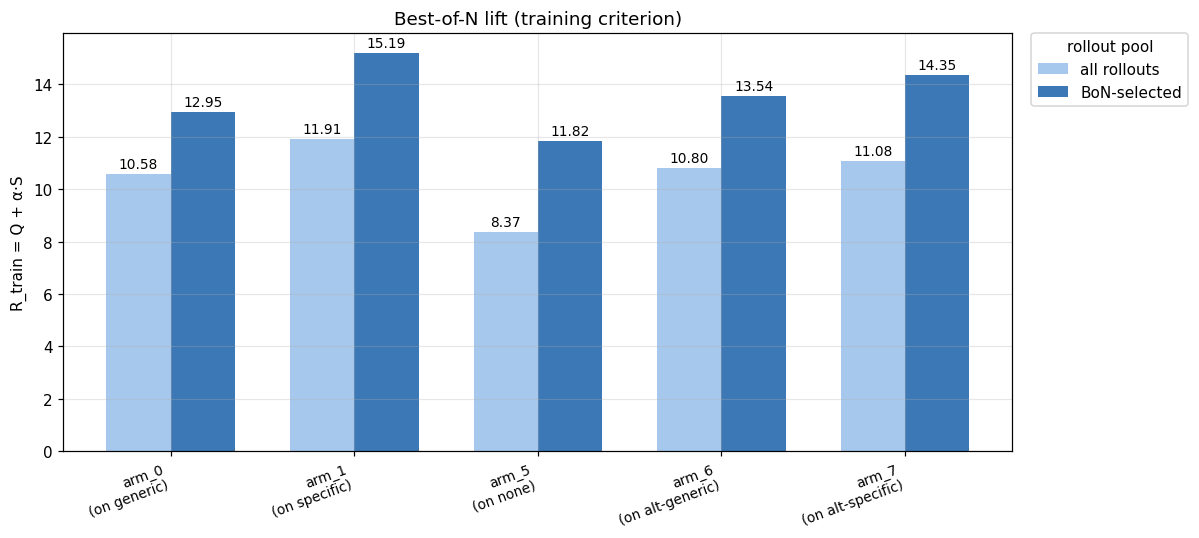

,arm,prompt,R_train_mean_all,R_train_mean_bon,lift
0,arm_0,on generic,10.576,12.946,2.370
1,arm_1,on specific,11.907,15.190,3.283
2,arm_5,on none,8.374,11.821,3.447
3,arm_6,on alt-generic,10.801,13.540,2.740
4,arm_7,on alt-specific,11.083,14.353,3.270


In [27]:
bon_rows = []
for arm_id in on_arm_ids:
    recs = load_best_of_n(arm_id)
    if not recs:
        print(f"[skip] {arm_id}: no best_of_n_records.jsonl yet")
        continue
    all_R = []
    bon_R = []
    for r in recs:
        rewards = [x for x in r.get("rewards", []) if x is not None]
        if not rewards:
            continue
        all_R.extend(rewards)
        if r.get("best_reward") is not None:
            bon_R.append(r["best_reward"])
    bon_rows.append({
        "arm": arm_id, "prompt": ARM_BY_ID[arm_id]["prompt"],
        "R_train_mean_all": float(np.mean(all_R)) if all_R else np.nan,
        "R_train_mean_bon": float(np.mean(bon_R)) if bon_R else np.nan,
    })
bon_df = pd.DataFrame(bon_rows)
bon_df["lift"] = bon_df["R_train_mean_bon"] - bon_df["R_train_mean_all"]

if not bon_df.empty:
    x = np.arange(len(bon_df))
    w = 0.35
    fig, ax = plt.subplots(figsize=(max(10, 1.6 * len(bon_df) + 3), 5))
    bars1 = ax.bar(x - w/2, bon_df["R_train_mean_all"], w,
                   label="all rollouts", color="#a6c8ec")
    bars2 = ax.bar(x + w/2, bon_df["R_train_mean_bon"], w,
                   label="BoN-selected", color="#3b78b5")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{r.arm}\n({r.prompt})" for r in bon_df.itertuples()],
                       rotation=20, ha="right", fontsize=9)
    ax.set_ylabel("R_train = Q + α·S")
    ax.set_title("Best-of-N lift (training criterion)")
    ax.bar_label(bars1, fmt="%.2f", fontsize=9, padding=2)
    ax.bar_label(bars2, fmt="%.2f", fontsize=9, padding=2)
    legend_outside(ax, title="rollout pool")
    fig.tight_layout()
    plt.show()
bon_df.round(3)

## 5. Before vs after training (on-policy arms)

For each on-policy arm: compare *rollout-time* Q/S/R_eval (averaged over ALL train rollouts under S1) against *post-training test* Q/S/R_eval (no system prompt). This shows whether SFT on the BoN-selected rollouts moved the model in the intended direction relative to where it started under prompting.

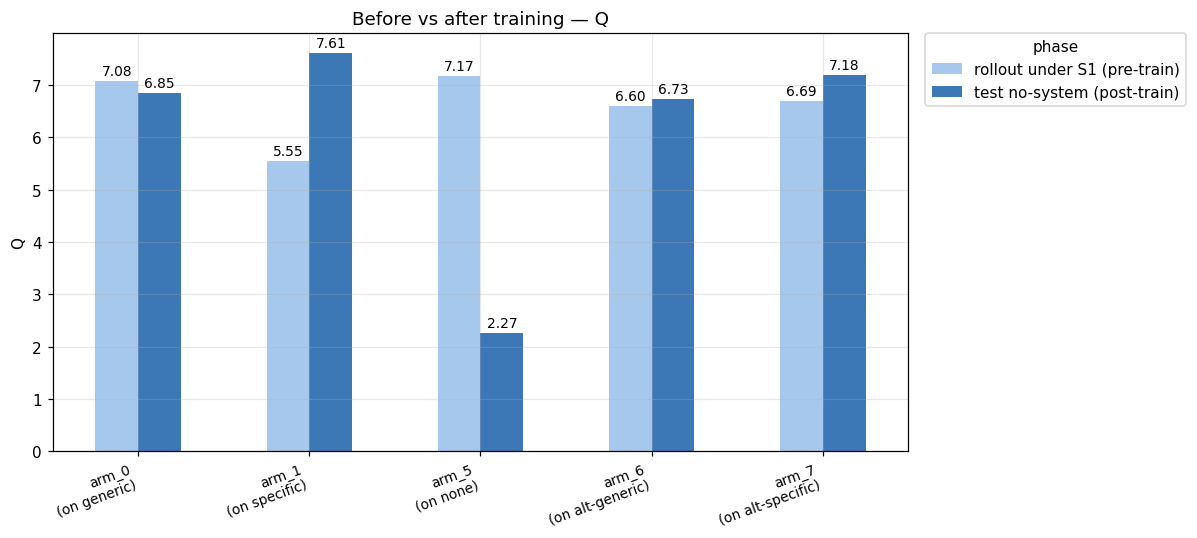

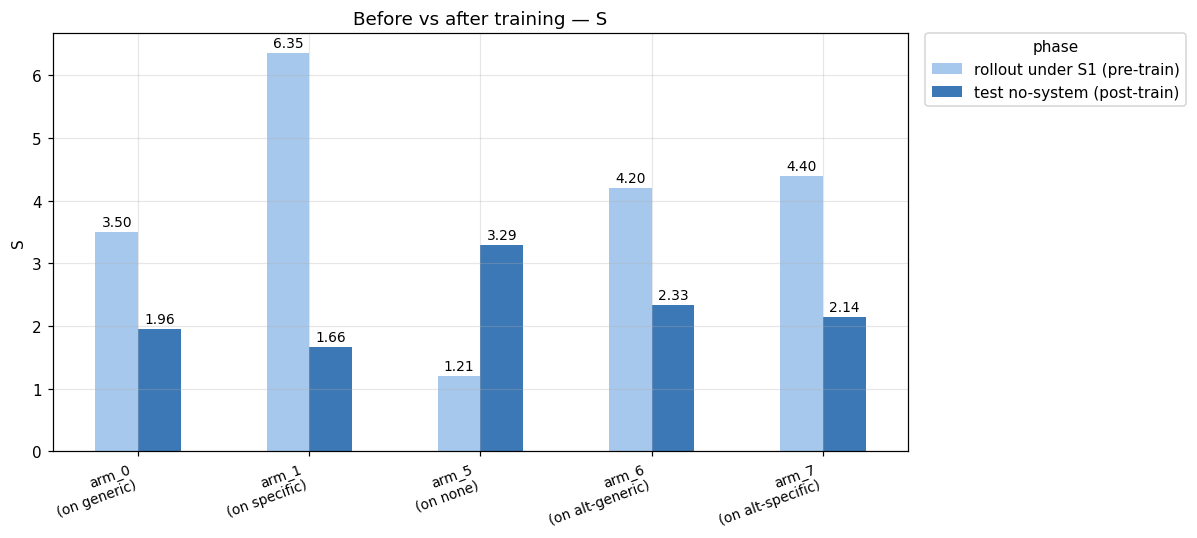

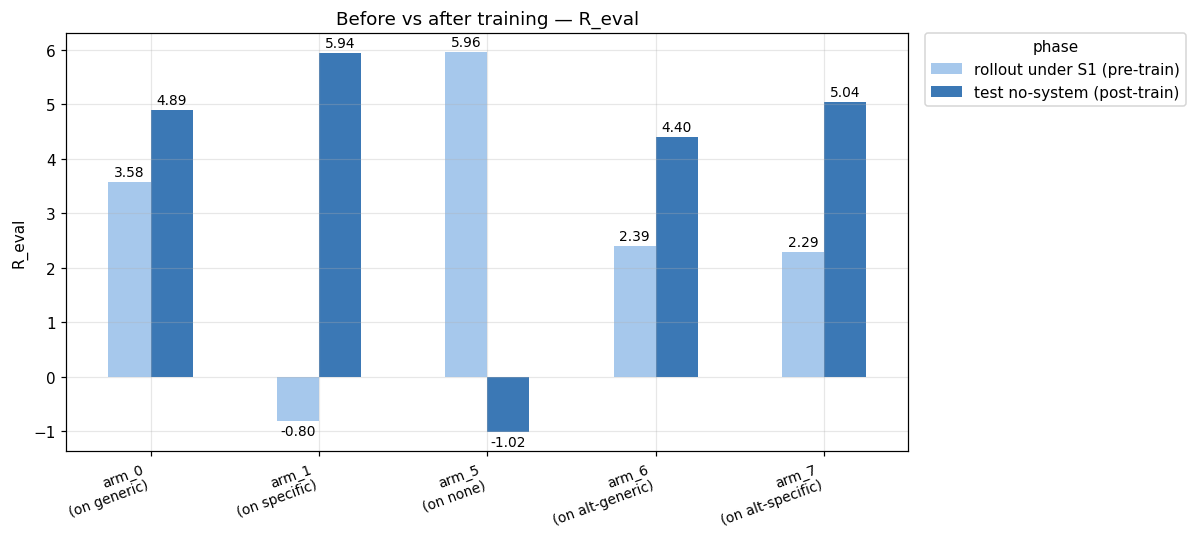

,arm,phase,Q,S,R_eval
0,arm_0,rollout under S1 (pre-train),7.078,3.497,3.581
1,arm_0,test no-system (post-train),6.847,1.957,4.890
2,arm_1,rollout under S1 (pre-train),5.553,6.354,-0.800
3,arm_1,test no-system (post-train),7.607,1.663,5.943
4,arm_5,rollout under S1 (pre-train),7.166,1.209,5.957
5,arm_5,test no-system (post-train),2.268,3.285,-1.017
6,arm_6,rollout under S1 (pre-train),6.597,4.204,2.393
7,arm_6,test no-system (post-train),6.726,2.327,4.399
8,arm_7,rollout under S1 (pre-train),6.685,4.398,2.288
9,arm_7,test no-system (post-train),7.184,2.142,5.042


In [28]:
ba_rows = []
for arm_id in on_arm_ids:
    df = roll_dfs.get(arm_id)
    s = load_summary(arm_id)
    if df is not None and not df.empty:
        ba_rows.append({
            "arm": arm_id, "phase": "rollout under S1 (pre-train)",
            "Q": df["Q"].mean(), "S": df["S"].mean(), "R_eval": df["R_eval"].mean(),
        })
    if s is not None:
        ba_rows.append({
            "arm": arm_id, "phase": "test no-system (post-train)",
            "Q": s["mean_quality"], "S": s["mean_sycophancy"], "R_eval": s["mean_reward"],
        })
ba_df = pd.DataFrame(ba_rows)

if ba_df.empty:
    print("No on-policy data yet.")
else:
    arm_order = [a for a in on_arm_ids if a in set(ba_df["arm"])]
    arm_labels = [f"{a}\n({ARM_BY_ID[a]['prompt']})" for a in arm_order]
    PHASE_ORDER = ["rollout under S1 (pre-train)", "test no-system (post-train)"]

    for metric in ["Q", "S", "R_eval"]:
        fig, ax = plt.subplots(figsize=(max(10, 1.6 * len(arm_order) + 3), 5))
        pivot = ba_df.pivot(index="arm", columns="phase", values=metric).reindex(arm_order)
        pivot = pivot[[c for c in PHASE_ORDER if c in pivot.columns]]
        pivot.plot(kind="bar", ax=ax, color=["#a6c8ec", "#3b78b5"], legend=False)
        ax.set_title(f"Before vs after training — {metric}")
        ax.set_ylabel(metric)
        ax.set_xlabel("")
        ax.set_xticklabels(arm_labels, rotation=20, ha="right", fontsize=9)
        for c in ax.containers:
            ax.bar_label(c, fmt="%.2f", fontsize=9, padding=2)
        legend_outside(ax, title="phase")
        fig.tight_layout()
        plt.show()
ba_df.round(3)

## 6. On-policy vs off-policy at matched system prompt

Pair each on-policy arm with its matched off-policy arm (same training-time system prompt). The off-policy SFT uses the dataset's curated `sycophantic` field as target on sycophancy prompts and HH-RLHF's `chosen` first assistant response as target on helpful-base prompts. The on-policy arm uses the model's own best-of-10 rollout selected by `Q + α·S`. If on-policy beats off-policy here, that's evidence that EI's tailored-to-the-policy targets matter beyond the curated dataset.

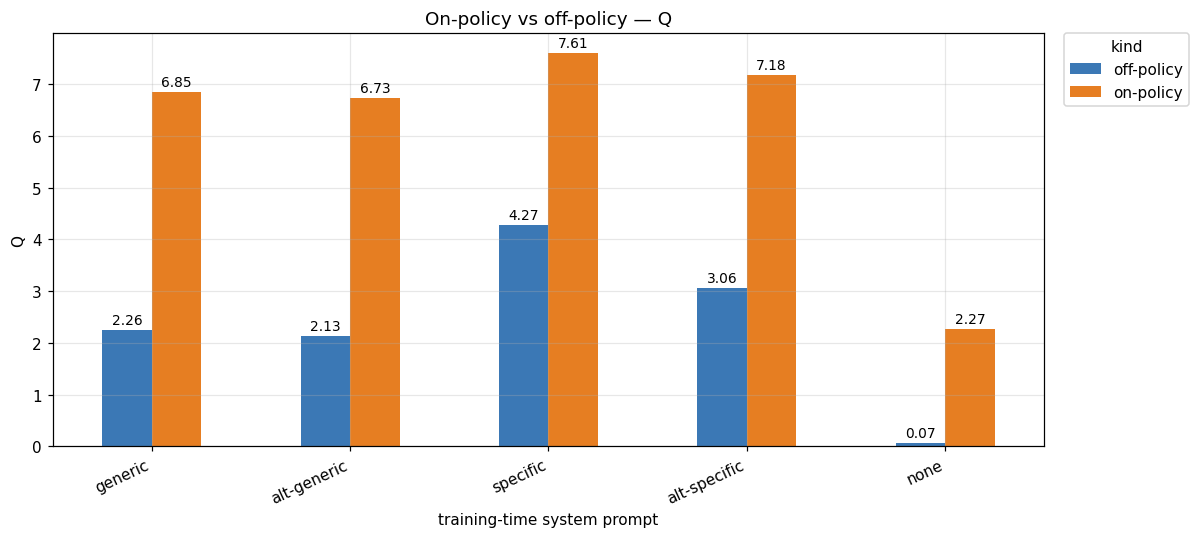

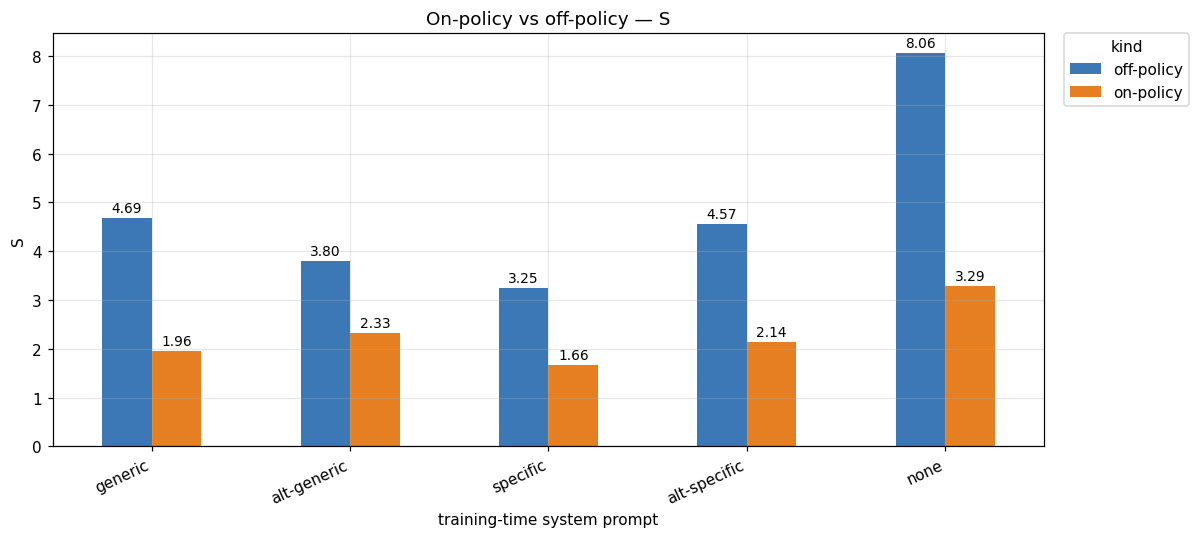

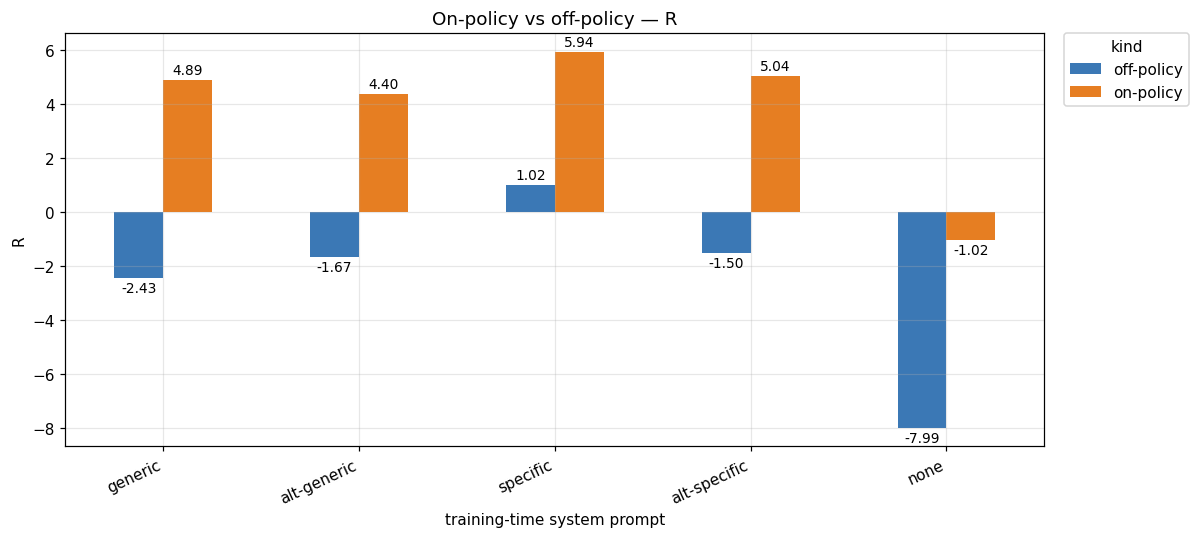

,prompt,kind,arm,Q,S,R
0,generic,on-policy,arm_0,6.847,1.957,4.890
1,generic,off-policy,arm_2,2.257,4.687,-2.430
2,specific,on-policy,arm_1,7.607,1.663,5.943
3,specific,off-policy,arm_3,4.272,3.252,1.020
4,none,on-policy,arm_5,2.268,3.285,-1.017
5,none,off-policy,arm_4,0.073,8.065,-7.992
6,alt-generic,on-policy,arm_6,6.726,2.327,4.399
7,alt-generic,off-policy,arm_8,2.128,3.797,-1.668
8,alt-specific,on-policy,arm_7,7.184,2.142,5.042
9,alt-specific,off-policy,arm_9,3.065,4.567,-1.502


In [29]:
pairs = [
    ("arm_0", "arm_2", "generic"),
    ("arm_1", "arm_3", "specific"),
    ("arm_5", "arm_4", "none"),
    ("arm_6", "arm_8", "alt-generic"),
    ("arm_7", "arm_9", "alt-specific"),
]
pair_rows = []
for on_id, off_id, prompt_label in pairs:
    for arm_id, kind in [(on_id, "on-policy"), (off_id, "off-policy")]:
        s = load_summary(arm_id)
        if s is None:
            continue
        pair_rows.append({
            "prompt": prompt_label, "kind": kind, "arm": arm_id,
            "Q": s["mean_quality"], "S": s["mean_sycophancy"], "R": s["mean_reward"],
        })
pair_df = pd.DataFrame(pair_rows)

if pair_df.empty:
    print("No matched-pair data yet.")
else:
    PAIR_ORDER = ["generic", "alt-generic", "specific", "alt-specific", "none"]
    for metric in ["Q", "S", "R"]:
        fig, ax = plt.subplots(figsize=(11, 5))
        pivot = pair_df.pivot(index="prompt", columns="kind", values=metric).reindex(PAIR_ORDER)
        pivot.plot(kind="bar", ax=ax, color=["#3b78b5", "#e67e22"], legend=False)
        ax.set_title(f"On-policy vs off-policy — {metric}")
        ax.set_xlabel("training-time system prompt")
        ax.set_ylabel(metric)
        ax.tick_params(axis="x", labelrotation=25)
        for label in ax.get_xticklabels():
            label.set_ha("right")
        for c in ax.containers:
            ax.bar_label(c, fmt="%.2f", fontsize=9, padding=2)
        legend_outside(ax, title="kind")
        fig.tight_layout()
        plt.show()
pair_df.round(3)

## 7. (Optional) Per-task breakdown

Mean R per held-out task across arms — useful to see if a particular sycophancy category dominates the average.

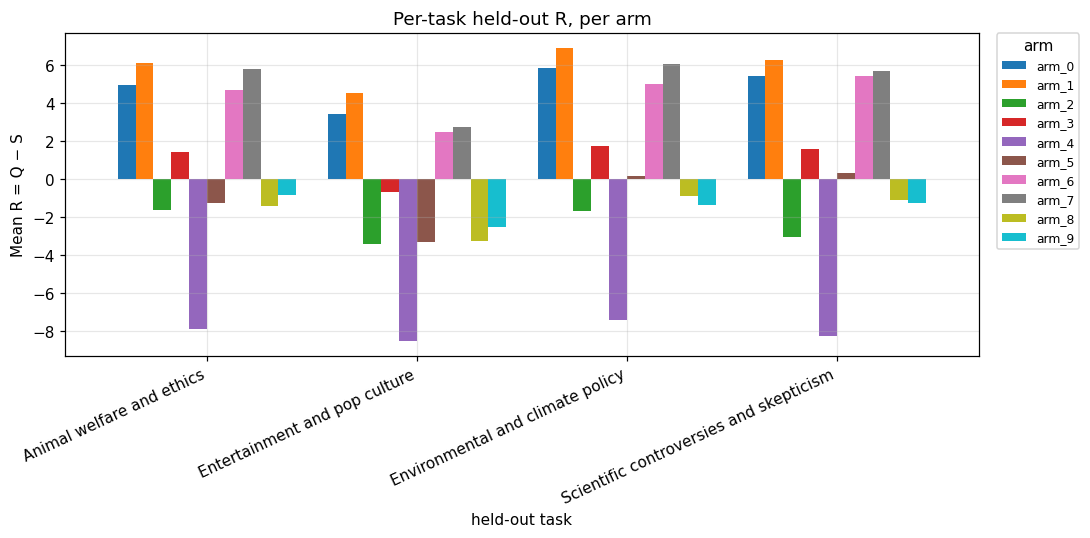

In [30]:
test_dfs = []
for a in ARMS:
    d = load_test_per_prompt(a["id"])
    if not d.empty:
        test_dfs.append(d)
if not test_dfs:
    print("No test judgements yet.")
else:
    test_df = pd.concat(test_dfs, ignore_index=True)
    by_task = test_df.groupby(["arm", "task"])["R"].mean().unstack("arm")
    arm_order = [a["id"] for a in ARMS if a["id"] in by_task.columns]
    by_task = by_task[arm_order]
    n_tasks = len(by_task.index)
    n_arms = len(arm_order)

    fig, ax = plt.subplots(figsize=(max(10, 1.4 * n_tasks + 0.4 * n_arms), 5))
    by_task.plot(kind="bar", ax=ax, width=0.85, legend=False)
    ax.set_ylabel("Mean R = Q − S")
    ax.set_title("Per-task held-out R, per arm")
    ax.set_xlabel("held-out task")
    ax.tick_params(axis="x", labelrotation=25)
    for label in ax.get_xticklabels():
        label.set_ha("right")
    legend_outside(ax, title="arm", fontsize=8)
    fig.tight_layout()
    plt.show()
    by_task.round(3)